# DAR direction & hour-angle tests (with KPNO pointing data)

Uses the per-exposure pointing/timing pulled from `exposure.exposure`
(`../dar_exposure_pointing.csv`) joined to the pooled standard-star losses, to run
the two tests that need pointing information — which the offline dataset alone could not do:

- **Test A — DAR direction.** On the Mayall's equatorial mount, DAR points along the parallactic
  angle in a *fixed* focal-plane frame. If the smooth loss dipole is DAR, its focal-plane
  direction must **rotate with the parallactic angle**; a fixed instrumental dipole would not.
  We fit the dipole as **fixed + rotating(q)** and compare the two amplitudes.
- **Test B — loss vs hour angle.** The DAR *drift* accumulated over a fixed-fiber exposure grows
  off the meridian (airmass changes fastest there). We test whether loss grows with |HA| / with
  the intra-exposure drift `|Δtan z|`.

A final section, **When did the loss change?**, uses only the loss dataset (no pointing) to answer
the *original* puzzle — why the loss increased, and whether the March-2026 PlateMaker change caused
it — with a time series and a three-epoch split.

The pointing columns were validated separately: `mountha` = ST − RA (RMS 0.25°), `zd` matches the
computed zenith distance (RMS 0.12°), and `parallactic` matches the standard formula to 0.27° RMS
for airmass > 1.3 (disagreeing only within a few degrees of the zenith, where it is undefined).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

FP = 410.0                        # focal-plane radius (mm) for normalizing X, Y
PHI = np.radians(31.9634)         # KPNO / Mayall latitude
SPLIT_NIGHT = 20260307

loss = pd.read_parquet("data/dar_calibstars_dataset.parquet")
pt = pd.read_csv("../data/dar_exposure_pointing.csv")
df = loss.merge(pt[["EXPID", "parallactic", "mountha", "skydec", "exptime"]], on="EXPID", how="left")
df["epoch"] = np.where(df.night > SPLIT_NIGHT, "after", "before")
print(f"{len(df):,} star-measurements, {df.EXPID.nunique():,} exposures; "
      f"pointing joined for {df.parallactic.notna().mean()*100:.1f}%")


def ols(A, y):
    """Least squares via normal equations (avoids the macOS/Accelerate matmul warnings)."""
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return np.linalg.solve(A.T @ A, A.T @ y)

2,570,324 star-measurements, 24,630 exposures; pointing joined for 100.0%


## Test A — does the loss dipole rotate with the parallactic angle?

**What "dipole" means here.** We fit the lowest-order spatial variation of the loss across the
focal plane — a **linear tilt** (a gradient). With each exposure's mean removed, a tilt on the
circular focal plane appears as **one side high (red), the opposite side low (blue), zero along the
middle** — the two-lobe / yin-yang look. We parametrize it by the **loss-gradient vector
`g = (g_x, g_y)`**: its direction is where loss rises fastest (`PA = atan2(g_x, g_y)`, from North
toward East) and its length is the tilt's steepness. The fit is simply

`loss ≈ g_x·x + g_y·y`

— the gradient `g` dotted with the star's focal-plane position `(x, y)`. Each term is one scalar
coefficient times one coordinate (`g_x·x` is *not* `g·x·x`).

**The test.** On the equatorial mount a DAR tilt must **rotate with the parallactic angle q**; a
fixed instrumental tilt would not. So we split the gradient into a fixed part and a part that
rotates with q:

`loss ≈ g_fix·r + g_rot(q)·r`, with `g_rot(q) = G·e^{i·s·q}` — a fixed complex amplitude `G` *turned*
by the parallactic angle each exposure, `r = (x, y)`, and `s = ±1` the sky↔focal-plane chirality.
In coordinates: `loss ≈ a·x + b·y + c·Re(w) + d·Im(w)` with `w = e^{-i·s·q}(x + i·y)`; then
`|g_fix| = √(a²+b²)` (instrumental) and `|G| = √(c²+d²)` (DAR). The x, y are the *same* star
positions in both terms — the rotating one just reads them in **zenith-aligned** axes (rotated by
q) rather than focal-plane axes.

In [2]:
sel = df[(df.airmass > 1.4) & df.parallactic.notna()].copy()
lc = (sel.loss - sel.groupby("EXPID").loss.transform("mean")).values   # per-exposure mean removed
x, y = sel.X.values / FP, sel.Y.values / FP                            # per-star focal-plane position
q = np.radians(sel.parallactic.values)
tss = float(np.sum(lc ** 2))
print(f"high-airmass sample (airmass>1.4): {sel.EXPID.nunique()} exposures, {len(sel):,} stars\n")


def rot_cols(s):                                    # star position read in zenith-aligned axes
    a = s * q
    return [np.cos(a) * x + np.sin(a) * y, np.cos(a) * y - np.sin(a) * x]   # Re(w), Im(w)


def fit(cols):
    A = np.column_stack(cols); c = ols(A, lc)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        r2 = 1 - np.sum((lc - A @ c) ** 2) / tss
    return c, r2


# (1) does a *rotating* tilt explain more than a *fixed* one, at equal parameter count?
c_fix, r2_fix = fit([x, y])
c_rp, r2_rp = fit(rot_cols(+1))
c_rm, r2_rm = fit(rot_cols(-1))
print("2-parameter tilt models (same # of parameters):")
print(f"  fixed (focal-plane axes):   |g| = {np.hypot(*c_fix)*1e3:5.2f}e-3   R2 = {r2_fix:.4f}")
print(f"  rotating with q, s=+1:      |g| = {np.hypot(*c_rp)*1e3:5.2f}e-3   R2 = {r2_rp:.4f}   <-- best")
print(f"  rotating with q, s=-1:      |g| = {np.hypot(*c_rm)*1e3:5.2f}e-3   R2 = {r2_rm:.4f}")
s_best = 1 if r2_rp >= r2_rm else -1

# (2) combined fixed + rotating (best chirality) with bootstrap-over-exposures errors on |g_fix|,|G|
A = np.column_stack([x, y] + rot_cols(s_best))
codes, exps = pd.factorize(sel.EXPID.values); nE = len(exps)
AtA = np.zeros((nE, 4, 4)); Aty = np.zeros((nE, 4))
for k in range(4):
    for j in range(4):
        AtA[:, k, j] = np.bincount(codes, A[:, k] * A[:, j], minlength=nE)
    Aty[:, k] = np.bincount(codes, A[:, k] * lc, minlength=nE)


def solve_w(w):
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return np.linalg.solve((AtA * w[:, None, None]).sum(0), (Aty * w[:, None]).sum(0))


c0 = solve_w(np.ones(nE)); fix0, rot0 = np.hypot(c0[0], c0[1]), np.hypot(c0[2], c0[3])
rng = np.random.default_rng(0); fb, rb = [], []
for _ in range(400):
    w = rng.multinomial(nE, np.full(nE, 1.0 / nE)).astype(float)
    c = solve_w(w); fb.append(np.hypot(c[0], c[1])); rb.append(np.hypot(c[2], c[3]))
fb, rb = np.array(fb), np.array(rb); dlt = rb - fb
print(f"\ncombined fit (s={s_best:+d}), bootstrap over exposures:")
print(f"  fixed (instrumental) |g_fix| = {fix0*1e3:5.2f} +/- {fb.std()*1e3:.2f} e-3")
print(f"  rotating (DAR)       |G|     = {rot0*1e3:5.2f} +/- {rb.std()*1e3:.2f} e-3")
print(f"  rotating - fixed = {dlt.mean()*1e3:+.2f} +/- {dlt.std()*1e3:.2f} e-3   ({dlt.mean()/dlt.std():.1f} sigma)")
print(f"  rotating variance fraction |G|^2/(|G|^2+|g_fix|^2) = {np.mean(rb**2/(rb**2+fb**2)):.2f}")

# (3) binned dipole direction vs q (for the figure)
sel["qbin"] = (np.floor(sel.parallactic / 15) * 15).astype(int)
rows = []
for qb, g in sel.groupby("qbin"):
    if g.EXPID.nunique() < 8:
        continue
    gc = (g.loss - g.groupby("EXPID").loss.transform("mean")).values
    gx, gy = ols(np.column_stack([g.X.values / FP, g.Y.values / FP]), gc)
    rows.append((qb + 7.5, g.EXPID.nunique(), np.degrees(np.arctan2(gx, gy)) % 360))
paq = pd.DataFrame(rows, columns=["q", "n_exp", "PA"])

high-airmass sample (airmass>1.4): 2968 exposures, 309,889 stars

2-parameter tilt models (same # of parameters):
  fixed (focal-plane axes):   |g| = 41.13e-3   R2 = 0.1115
  rotating with q, s=+1:      |g| = 44.62e-3   R2 = 0.1300   <-- best
  rotating with q, s=-1:      |g| = 30.42e-3   R2 = 0.0607

combined fit (s=+1), bootstrap over exposures:
  fixed (instrumental) |g_fix| = 28.70 +/- 1.10 e-3
  rotating (DAR)       |G|     = 35.78 +/- 1.04 e-3
  rotating - fixed = +7.03 +/- 1.49 e-3   (4.7 sigma)
  rotating variance fraction |G|^2/(|G|^2+|g_fix|^2) = 0.61


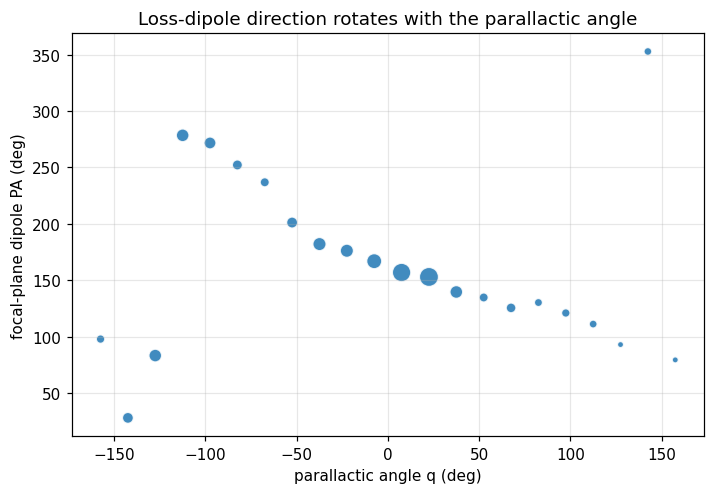

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.scatter(paq.q, paq.PA, s=np.sqrt(paq.n_exp) * 6, c="C0", alpha=0.85, edgecolor="w")
ax.set_xlabel("parallactic angle q (deg)")
ax.set_ylabel("focal-plane dipole PA (deg)")
ax.set_title("Loss-dipole direction rotates with the parallactic angle")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading Test A.** Two independent ways the tilt is shown to *follow the sky*:

- **A rotating tilt explains more than a fixed one at equal parameter count:** R²(rotating, s=+1)
  ≈ 0.130 vs R²(fixed) ≈ 0.111, and the sky↔focal-plane chirality is resolved (s=+1: 0.130 vs
  s=−1: 0.061).
- **In the combined fit the rotating (DAR) amplitude exceeds the fixed (instrumental) one at
  ~4.7σ** (≈36 vs ≈29 ×10⁻³; bootstrap over exposures), carrying **~60% of the dipole variance**.

So the smooth dipole is a **mix**: the larger part is a tilt that rotates with the parallactic
angle — **DAR** — on top of a real, smaller *fixed* instrumental tilt. The figure shows the raw
version: the dipole PA swings monotonically with q. This is a direct, geometric confirmation of
DAR, independent of the tan z·sec²z argument. (Per-star R² is small only because one coherent tilt
sits under large per-star photon/petal scatter; the model comparison and the 4.7σ amplitude
ordering are what matter, over ~3×10⁵ stars.)

## Test B — the excess scales with the DAR-rotation drift

Near the meridian the residual DAR offset changes mainly by **rotating** (the parallactic angle q
sweeps fastest at transit), not by changing length. The drift this produces over an exposure is

`rotation drift = tan z · Δq`,   with `Δq = dq/dt · T` (parallactic angle swept in exposure time T).

So it should grow with **airmass** (tan z), be largest **at the meridian** (dq/dt peaks at transit),
and grow with **exposure time** (T). We test the after−before excess against each factor.

In [4]:
def _q(H, dec):
    return np.degrees(np.arctan2(np.sin(np.radians(H)),
                     np.tan(PHI) * np.cos(np.radians(dec)) - np.sin(np.radians(dec)) * np.cos(np.radians(H))))

def _tanz(H, dec):
    cz = np.sin(PHI) * np.sin(np.radians(dec)) + np.cos(PHI) * np.cos(np.radians(dec)) * np.cos(np.radians(H))
    return np.tan(np.arccos(np.clip(cz, -1, 1)))

_wrap = lambda a: (a + 180) % 360 - 180
ex = pt.dropna(subset=["mountha", "skydec", "exptime"]).copy()
dHA = ex.exptime / 240.0                                       # deg of HA swept during the exposure
ex["dq"] = np.abs(_wrap(_q(ex.mountha + dHA, ex.skydec) - _q(ex.mountha, ex.skydec)))   # parallactic sweep
ex["rotdrift"] = _tanz(ex.mountha + dHA / 2, ex.skydec) * np.radians(ex.dq)             # tan z * Δq
d2 = df.merge(ex[["EXPID", "dq", "rotdrift"]], on="EXPID", how="left")
d2["absha"] = d2.mountha.abs()

# LEFT PANEL: mean loss vs |HA| in airmass bins, before vs after
ambins = [(1.0, 1.3), (1.3, 1.6), (1.6, 2.05)]
habins = [(0, 10), (10, 20), (20, 35), (35, 90)]
ha_curves = {}
for alo, ahi in ambins:
    xs, b_row, a_row = [], [], []
    for hlo, hhi in habins:
        sub = d2[(d2.airmass >= alo) & (d2.airmass < ahi) & (d2.absha >= hlo) & (d2.absha < hhi)]
        b = sub[sub.epoch == "before"]; a = sub[sub.epoch == "after"]
        xs.append((hlo + hhi) / 2)
        b_row.append(b.loss.mean() * 1e3 if len(b) > 200 else np.nan)
        a_row.append(a.loss.mean() * 1e3 if len(a) > 200 else np.nan)
    ha_curves[(alo, ahi)] = (xs, b_row, a_row)
    print(f"loss vs |HA| airmass {alo}-{ahi}:  before {[round(v,2) for v in b_row]}   after {[round(v,2) for v in a_row]}")

# RIGHT PANEL: exposure-time split at fixed geometry & seeing (after, airmass>1.4, near meridian)
et = d2[(d2.epoch == "after") & (d2.airmass > 1.4) & (d2.absha < 25) & d2.seeing.between(0.9, 1.5)].copy()
et["tbin"] = pd.qcut(et.exptime, 3, labels=False, duplicates="drop")
rng = np.random.default_rng(0)
et_rows = []
for tb, g in et.groupby("tbin"):
    ge = g.groupby("EXPID").loss.agg(["sum", "count"]); s, c, n = ge["sum"].values, ge["count"].values, len(ge)
    boot = [(s * w).sum() / (c * w).sum()
            for w in (rng.multinomial(n, np.full(n, 1.0 / n)).astype(float) for _ in range(300))]
    et_rows.append(dict(exptime=g.exptime.median(), loss=g.loss.mean(),
                        lo=np.percentile(boot, 16), hi=np.percentile(boot, 84),
                        seeing=g.seeing.median(), airmass=g.airmass.median(), nexp=n))
etc = pd.DataFrame(et_rows)
print("\nexposure-time split (after, airmass>1.4, |HA|<25, seeing 0.9-1.5 held fixed):")
print(etc.assign(loss_x1e3=(etc.loss * 1e3).round(2), exptime=etc.exptime.round(0),
                 seeing=etc.seeing.round(2), airmass=etc.airmass.round(2))
      [["exptime", "seeing", "airmass", "nexp", "loss_x1e3"]].to_string(index=False))

loss vs |HA| airmass 1.0-1.3:  before [np.float64(0.15), np.float64(0.07), np.float64(0.23), np.float64(0.47)]   after [np.float64(0.67), np.float64(0.98), np.float64(0.86), np.float64(0.36)]
loss vs |HA| airmass 1.3-1.6:  before [np.float64(-0.03), np.float64(-0.18), np.float64(0.64), np.float64(1.2)]   after [np.float64(1.87), np.float64(0.75), np.float64(2.3), np.float64(2.15)]
loss vs |HA| airmass 1.6-2.05:  before [np.float64(1.75), np.float64(3.33), np.float64(3.33), np.float64(4.38)]   after [np.float64(16.79), np.float64(11.38), np.float64(7.17), np.float64(5.36)]

exposure-time split (after, airmass>1.4, |HA|<25, seeing 0.9-1.5 held fixed):
 exptime  seeing  airmass  nexp  loss_x1e3
   651.0    1.08     1.48    21       1.67
  1163.0    1.06     1.46    24       1.16
  1508.0    1.12     1.50    22       7.37


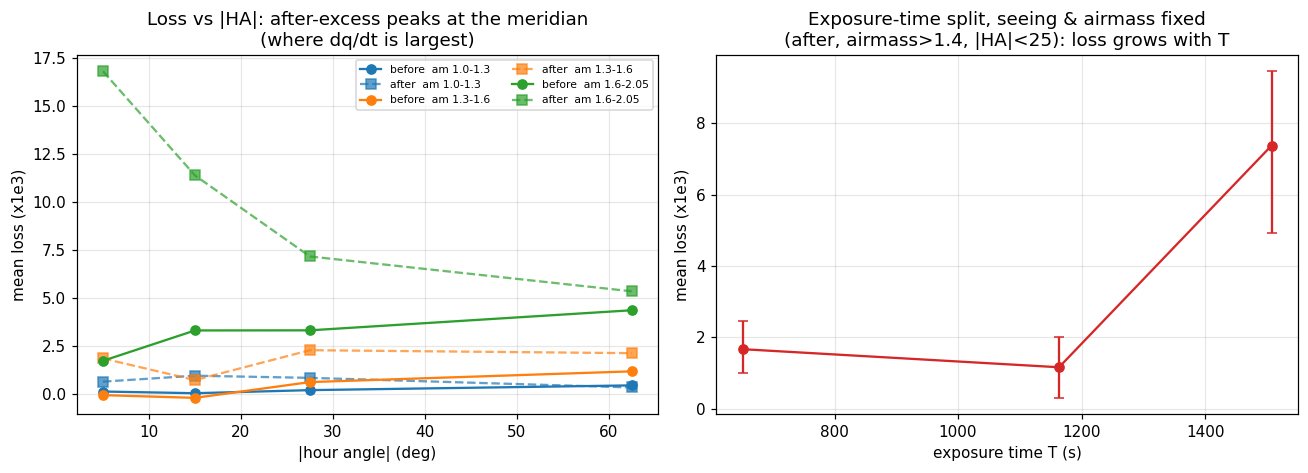

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

for (alo, ahi), (xs, b_row, a_row) in ha_curves.items():
    line, = ax1.plot(xs, b_row, "o-", label=f"before  am {alo}-{ahi}")
    ax1.plot(xs, a_row, "s--", color=line.get_color(), alpha=0.7, label=f"after  am {alo}-{ahi}")
ax1.set_xlabel("|hour angle| (deg)"); ax1.set_ylabel("mean loss (x1e3)")
ax1.set_title("Loss vs |HA|: after-excess peaks at the meridian\n(where dq/dt is largest)")
ax1.legend(fontsize=7, ncol=2); ax1.grid(alpha=0.3)

ax2.errorbar(etc.exptime, etc.loss * 1e3,
             yerr=[(etc.loss - etc.lo) * 1e3, (etc.hi - etc.loss) * 1e3],
             fmt="o-", color="C3", capsize=3)
ax2.set_xlabel("exposure time T (s)"); ax2.set_ylabel("mean loss (x1e3)")
ax2.set_title("Exposure-time split, seeing & airmass fixed\n(after, airmass>1.4, |HA|<25): loss grows with T")
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### The combined rotation drift `tan z · Δq`  (extra view — one variable)

Both geometry and time folded into one axis: mean loss vs the parallactic rotation actually swept
per exposure. Within either epoch the loss rises with the drift — the signature of the intra-exposure
DAR rotation. (The vertical *offset* between the before and after curves is **not** a code effect: it
is the mid-2025 calibration shift isolated in the final section — the "before" sample blends the flat
pre-2025 epoch with the risen 2025+ epoch.)

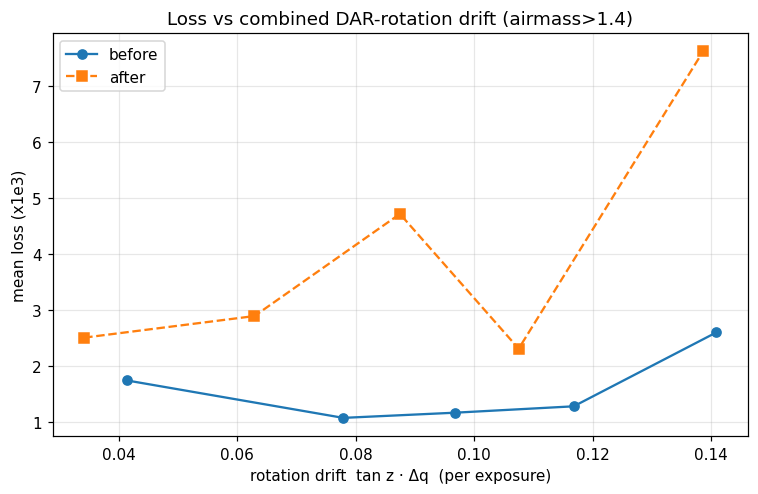

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.6))
for ep, fmt, col in [("before", "o-", "C0"), ("after", "s--", "C1")]:
    dd = d2[(d2.epoch == ep) & (d2.airmass > 1.4) & d2.rotdrift.notna()].copy()
    dd["db"] = pd.qcut(dd.rotdrift, 5, labels=False, duplicates="drop")
    g = dd.groupby("db").agg(drift=("rotdrift", "median"), loss=("loss", "mean"))
    ax.plot(g.drift, g.loss * 1e3, fmt, color=col, label=ep)
ax.set_xlabel("rotation drift  tan z · Δq  (per exposure)")
ax.set_ylabel("mean loss (x1e3)")
ax.set_title("Loss vs combined DAR-rotation drift (airmass>1.4)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading Test B.** The loss scales with the **DAR-rotation drift** `tan z · dq/dt · T` on
all three factors:

- **dq/dt** — the loss **peaks at the meridian** (left panel), where the parallactic angle sweeps
  fastest; a magnitude/ZD drift would instead *grow off-meridian*, so this rules that out.
- **T** — with **seeing and airmass held fixed**, mean loss **grows with exposure time** (right
  panel; ~2–2.6× for ~2× the time), so the effect is genuinely *time-integrated*, not a conditions
  confound.
- **combined** — loss tracks the actual rotation drift `tan z · Δq`.

This is the physics of the **airmass dependence** of the loss, and it holds in every epoch. The
vertical *offset* between the before and after curves is **not** a code effect — it is the mid-2025
calibration shift isolated in the final section (the "before" sample blends the flat pre-2025 epoch
with the risen 2025+ epoch). The standard **dither sequences do not reveal the rotation drift**,
because they use short (3-min) exposures over which very little rotation accumulates.

## Off-meridian scheduling: is transit actually the worst place?

Since the excess peaks at the meridian (largest `dq/dt`), one might hope to observe a *given* low-Dec
field off the meridian instead — trading higher airmass for lower `dq/dt`. We compute the DAR drift
of a 20-min exposure vs where in hour angle it is placed (fiber 300 mm from center).

In [7]:
def _z_q(H, dec):
    H = np.radians(H); d = np.radians(dec)
    z = np.arccos(np.sin(PHI) * np.sin(d) + np.cos(PHI) * np.cos(d) * np.cos(H))
    q = np.arctan2(np.sin(H), np.tan(PHI) * np.cos(d) - np.sin(d) * np.cos(H))
    return z, q

R0, PLATE = 60.0, 14.0                       # refraction constant (arcsec); plate scale (arcsec/mm)
UM = 1000.0 / PLATE                          # microns per arcsec
rho = np.radians(300 * PLATE / 3600.0)       # field offset of a fiber 300 mm from center


def drift_um(dec, HAc, T=1200.0):            # DAR field-offset drift over a T-second exposure centered at HAc
    t = np.linspace(0, T, 121); HA = HAc - 2.5 + t / 240.0
    z = np.array([_z_q(h, dec)[0] for h in HA]); q = np.array([_z_q(h, dec)[1] for h in HA])
    _, qmid = _z_q(HAc, dec); mag = R0 / np.cos(z) ** 2 * rho * np.cos(q - qmid)
    d = np.column_stack([mag * np.cos(q) * UM, mag * np.sin(q) * UM])
    return np.hypot(*(d[-1] - d[0])), 1 / np.cos(_z_q(HAc, dec)[0])


for dec in (-25, -40):
    print(f"Dec={dec}:  20-min exposure centered at HA  ->  (airmass, DAR drift)")
    for HAc in (0, 7.5, 15, 30, 45):
        dr, am = drift_um(dec, HAc)
        print(f"   HA={HAc:5.1f} deg ({HAc/15:.1f} h): airmass {am:.2f},  drift {dr:6.1f} um")

Dec=-25:  20-min exposure centered at HA  ->  (airmass, DAR drift)
   HA=  0.0 deg (0.0 h): airmass 1.83,  drift   26.0 um
   HA=  7.5 deg (0.5 h): airmass 1.86,  drift   28.0 um
   HA= 15.0 deg (1.0 h): airmass 1.93,  drift   34.7 um
   HA= 30.0 deg (2.0 h): airmass 2.26,  drift   75.3 um
   HA= 45.0 deg (3.0 h): airmass 3.13,  drift  261.4 um
Dec=-40:  20-min exposure centered at HA  ->  (airmass, DAR drift)
   HA=  0.0 deg (0.0 h): airmass 3.23,  drift   71.1 um
   HA=  7.5 deg (0.5 h): airmass 3.29,  drift   86.5 um
   HA= 15.0 deg (1.0 h): airmass 3.48,  drift  134.9 um
   HA= 30.0 deg (2.0 h): airmass 4.49,  drift  472.2 um
   HA= 45.0 deg (3.0 h): airmass 8.38,  drift 4433.1 um


**No — transit is already optimal.** For a *fixed* field the drift is smallest at transit and
grows steeply off-meridian: as the field leaves the meridian `dq/dt` falls but `tan z` rises (the
product stays ~flat) and the previously-zero magnitude drift switches on, so the total only
increases. The earlier "loss peaks at the meridian" is a *fixed-airmass* statement (comparing
different fields); this is the *fixed-field* slice, and it flips because airmass changes. The drift
cannot be scheduled away in hour angle — only shortened (exposure duration) or avoided at
field-selection.

## When did the loss change? — the epoch / time-series resolution

The tests above explain the **airmass dependence** of the loss (DAR rotation drift). They do not, by
themselves, explain the *original* puzzle: why the standard-star loss **increased**, and whether the
2026-03-07 PlateMaker change caused it. That is a question of **timing**, and it needs only the loss
dataset (no pointing) — so we answer it here to close the loop.

First, mean loss vs time, split by airmass (3-month rolling mean; July 2026 dropped as
weather-limited and non-representative):

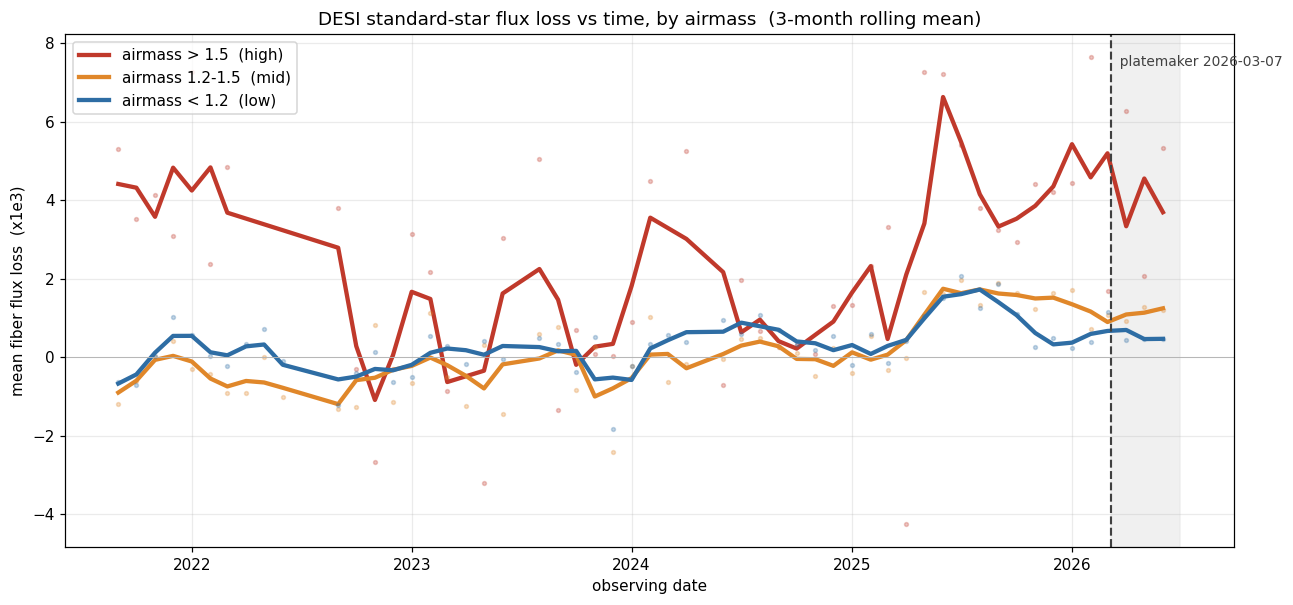

In [8]:
import matplotlib.dates as mdates

ee = loss.groupby("EXPID").agg(loss=("loss", "mean"), airmass=("airmass", "first"),
                               night=("night", "first")).reset_index()
ee = ee[ee.night < 20260701].copy()                     # drop July 2026 (weather-limited)
ee["date"] = pd.to_datetime(ee.night.astype(str), format="%Y%m%d")
ee["ym"] = ee.date.dt.to_period("M")
cut = pd.Timestamp("2026-03-07")                         # PlateMaker change

def series(mask):
    m = ee[mask].groupby("ym").loss.mean()
    return m.index.to_timestamp(), m * 1e3, m.rolling(3, center=True, min_periods=2).mean() * 1e3

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.axvspan(cut, ee.date.max(), color="0.9", alpha=.6, zorder=0)
for mask, lab, c in [(ee.airmass > 1.5, "airmass > 1.5  (high)", "#c0392b"),
                     ((ee.airmass > 1.2) & (ee.airmass < 1.5), "airmass 1.2-1.5  (mid)", "#e0872a"),
                     (ee.airmass < 1.2, "airmass < 1.2  (low)", "#2e6da4")]:
    x, y, r = series(mask)
    ax.plot(x, y, "o", ms=2.5, color=c, alpha=.28)
    ax.plot(x, r, "-", lw=2.8, color=c, label=lab)
ax.axvline(cut, color="0.25", ls="--", lw=1.4)
ax.text(cut, ax.get_ylim()[1] * 0.9, "  platemaker 2026-03-07", color="0.25", fontsize=9)
ax.axhline(0, color="0.7", lw=.6)
ax.set_ylabel("mean fiber flux loss  (x1e3)"); ax.set_xlabel("observing date")
ax.set_title("DESI standard-star flux loss vs time, by airmass  (3-month rolling mean)")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=10, loc="upper left"); ax.grid(alpha=.25)
plt.tight_layout()
plt.savefig("figures/rpt_loss_timeseries_combined.png", dpi=135, bbox_inches="tight")
plt.show()

Three things read off the time series: the rise is **airmass-graded** (high ≫ mid > low);
**even low airmass lifts off its flat pre-2025 baseline** (so a genuine systematic sits underneath,
where DAR is negligible); and there is **no step at the PlateMaker line** — the climb is underway
well before 2026-03-07.

To sharpen it, split into three epochs and compare mean loss vs airmass directly — **A** before
2025-03 (the flat baseline), **B** from 2025-03 to the 2026-03-07 PlateMaker change, **C** after:

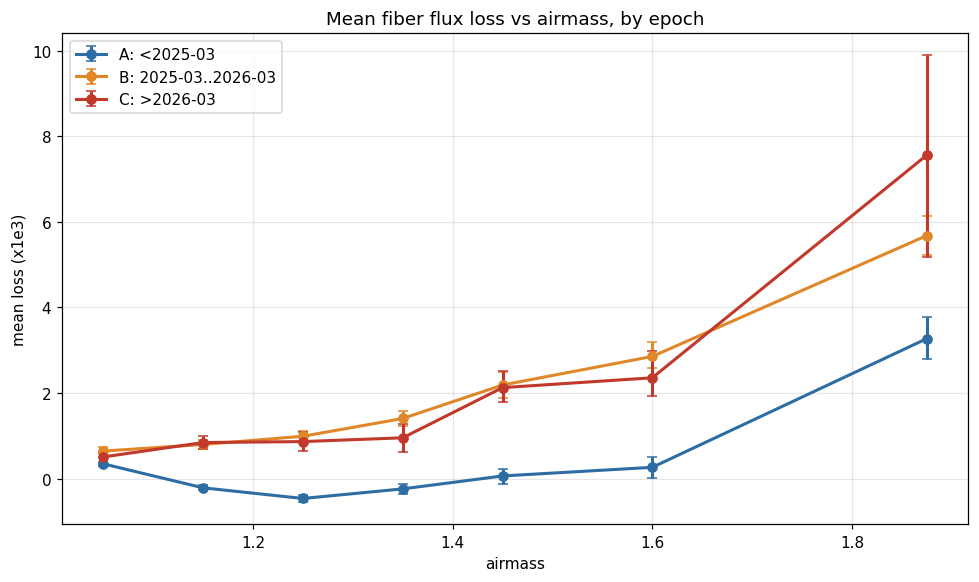

mean loss (x1e3), bootstrap-over-exposures 16-84% CI:
 LOW  airmass 1.0-1.2 (DAR-free -> isolates the systematic):
    A: <2025-03           :  0.12  CI[ 0.08, 0.15]  n=11591
    B: 2025-03..2026-03   :  0.70  CI[ 0.64, 0.76]  n=2982
    C: >2026-03           :  0.67  CI[ 0.57, 0.76]  n=919
 HIGH airmass 1.5-2.05 (where a platemaker effect would live):
    A: <2025-03           :  0.97  CI[ 0.74, 1.16]  n=953


    B: 2025-03..2026-03   :  4.11  CI[ 3.83, 4.39]  n=635
    C: >2026-03           :  3.89  CI[ 3.12, 4.59]  n=112


In [9]:
ee3 = loss.groupby("EXPID").agg(loss=("loss", "mean"), airmass=("airmass", "first"),
                                night=("night", "first")).reset_index()
ee3 = ee3[ee3.night < 20260701].copy()                  # drop July 2026 (weather-limited)

def epoch(n):
    return np.where(n < 20250301, "A: <2025-03",
                    np.where(n <= 20260307, "B: 2025-03..2026-03", "C: >2026-03"))

ee3["ep"] = epoch(ee3.night.values)
edges = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.7, 2.05]); ctr = (edges[:-1] + edges[1:]) / 2
rng = np.random.default_rng(0)
cols = {"A: <2025-03": "#2e6da4", "B: 2025-03..2026-03": "#e0872a", "C: >2026-03": "#c0392b"}

fig, ax = plt.subplots(figsize=(9, 5.4))
for ep, c in cols.items():
    g = ee3[ee3.ep == ep]; ys = []; lo_ = []; hi_ = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        s = g[(g.airmass >= lo) & (g.airmass < hi)]; n = len(s)
        if n < 8:
            ys.append(np.nan); lo_.append(np.nan); hi_.append(np.nan); continue
        boot = [s.loss.sample(n, replace=True, random_state=int(rng.integers(1e9))).mean() for _ in range(300)]
        ys.append(s.loss.mean() * 1e3); lo_.append(np.percentile(boot, 16) * 1e3); hi_.append(np.percentile(boot, 84) * 1e3)
    ys, lo_, hi_ = np.array(ys), np.array(lo_), np.array(hi_)
    ax.errorbar(ctr, ys, yerr=[ys - lo_, hi_ - ys], fmt="o-", color=c, capsize=3, label=ep, lw=2)
ax.set_xlabel("airmass"); ax.set_ylabel("mean loss (x1e3)")
ax.set_title("Mean fiber flux loss vs airmass, by epoch")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
plt.savefig("figures/rpt_threeepoch_airmass.png", dpi=130, bbox_inches="tight")
plt.show()

# the two diagnostic slices: DAR-free low airmass, and the high-airmass platemaker test
print("mean loss (x1e3), bootstrap-over-exposures 16-84% CI:")
for lab, lo, hi in [("LOW  airmass 1.0-1.2 (DAR-free -> isolates the systematic)", 1.0, 1.2),
                    ("HIGH airmass 1.5-2.05 (where a platemaker effect would live)", 1.5, 2.05)]:
    print(f" {lab}:")
    for ep in cols:
        s = ee3[(ee3.ep == ep) & (ee3.airmass >= lo) & (ee3.airmass < hi)]
        boot = [s.loss.sample(len(s), replace=True, random_state=int(rng.integers(1e9))).mean() for _ in range(400)]
        print(f"    {ep:22s}: {s.loss.mean()*1e3:5.2f}  CI[{np.percentile(boot,16)*1e3:5.2f},{np.percentile(boot,84)*1e3:5.2f}]  n={len(s)}")

**Reading it.** The A→B jump is large and significant at *both* airmasses (low 0.12→0.70,
high 0.97→4.11; intervals nowhere near overlapping) — the mid-2025 systematic. **B→C is null** (low
0.70 vs 0.67, high 4.11 vs 3.89; intervals fully overlap): the B and C curves lie on top of each
other, so **the PlateMaker change added nothing at any airmass.**

The **low-airmass** jump is the decisive piece: where DAR is negligible, positioning and atmosphere
cannot create a loss, yet the loss still rose A→B — isolating a **calibration- / measurement-level**
change around mid-2025 (something in how `RCALIBFRAC` is produced). We flag that to Data Systems and
do **not** diagnose its origin here (it need not be an offline-pipeline change; a genuine instrument
or software effect would look the same). What is firm: the increase is **not** the PlateMaker (B≈C)
and **not** purely DAR (it appears at low airmass). The original two-epoch before/after "excess" was
an artifact of a split straddling this mid-2025 transition.